<a href="https://colab.research.google.com/github/sangosei7/Data-Science-Portfolio/blob/main/Pokemon_Wrangling_and_Classification_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto 3: Ingeniería de Datos y Clasificación Multiclase de Pokémon
**Autor:** Santiago Obando

## 1. Introducción
En este proyecto, exploramos un dataset de Pokémon para demostrar habilidades en:
* **Data Wrangling:** Extracción de datos estructurados a partir de cadenas de texto complejas.
* **Exploratory Data Analysis (EDA):** Identificación de patrones físicos y de combate.
* **Machine Learning:** Clasificación de tipos principales basados en estadísticas base.

El objetivo principal es transformar datos brutos en insights accionables y un modelo predictivo.

# Project 3: Data Engineering and Multiclass Classification of Pokémon
**Author:** Santiago Obando

## 1. Introduction
In this project, we explore a comprehensive Pokémon dataset to demonstrate proficiency in:

* **Data Wrangling:** Extracting structured data from complex, unformatted text strings (feature parsing).
* **Exploratory Data Analysis (EDA):** Identifying combat patterns and physical attribute correlations.
* **Machine Learning:** Developing a multiclass classification model to predict primary types based on base stats.

The primary objective is to demonstrate the end-to-end process of transforming raw, messy data into actionable insights and a high-performing predictive model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo para visualizaciones profesionales
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Cargar el dataset
# Asegúrate de haber subido 'pokemon_data.csv' a la carpeta de archivos en Colab
df = pd.read_csv('pokemon_data.csv')

print(f"Dataset cargado con {df.shape[0]} registros y {df.shape[1]} columnas.")

# 2. Data Wrangling: Procesamiento de la columna 'stats'
# Esta columna viene como: "hp=45, attack=49, defense=49..."
# Vamos a convertirla en columnas individuales numéricas.

def extract_stats(stat_str):
    # Diccionario temporal para almacenar los valores
    s_dict = {}
    items = stat_str.split(', ')
    for item in items:
        key, val = item.split('=')
        s_dict[key.strip()] = int(val)
    return pd.Series(s_dict)

# Aplicamos la función y expandimos el dataframe
stats_expanded = df['stats'].apply(extract_stats)
df = pd.concat([df.drop('stats', axis=1), stats_expanded], axis=1)

# 3. Ingeniería de Características (Feature Engineering) Inicial
# Creamos el 'Total_Stats' que es un indicador clave en Pokémon
df['total_stats'] = df[['hp', 'attack', 'defense', 'special-attack', 'special-defense', 'speed']].sum(axis=1)

# Extraemos el tipo primario (el primero que aparece en la lista)
df['primary_type'] = df['types'].apply(lambda x: x.split(',')[0].strip())

print("Limpieza inicial completada. Columnas generadas:")
print(df.columns.tolist())
df.head()

Dataset cargado con 1302 registros y 9 columnas.
Limpieza inicial completada. Columnas generadas:
['id', 'name', 'base_experience', 'height', 'weight', 'types', 'abilities', 'moves', 'hp', 'attack', 'defense', 'special-attack', 'special-defense', 'speed', 'total_stats', 'primary_type']


,id,name,base_experience,height,weight,types,abilities,moves,hp,attack,defense,special-attack,special-defense,speed,total_stats,primary_type
0,1,bulbasaur,64,7,69,"grass, poison","overgrow, chlorophyll","razor-wind, swords-dance, cut, bind, vine-whip",45,49,49,65,65,45,318,grass
1,2,ivysaur,142,10,130,"grass, poison","overgrow, chlorophyll","swords-dance, cut, bind, vine-whip, headbutt",60,62,63,80,80,60,405,grass
2,3,venusaur,236,20,1000,"grass, poison","overgrow, chlorophyll","swords-dance, cut, bind, vine-whip, headbutt",80,82,83,100,100,80,525,grass
3,4,charmander,62,6,85,fire,"blaze, solar-power","mega-punch, fire-punch, thunder-punch, scratch...",39,52,43,60,50,65,309,fire
4,5,charmeleon,142,11,190,fire,"blaze, solar-power","mega-punch, fire-punch, thunder-punch, scratch...",58,64,58,80,65,80,405,fire


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Global visual settings for professional plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Data Acquisition
# Ensure 'pokemon_data.csv' is uploaded to your Colab session
df = pd.read_csv('pokemon_data.csv')

print(f"Dataset successfully loaded with {df.shape[0]} records and {df.shape[1]} columns.")

# 2. Data Wrangling: Parsing the 'stats' column
# The 'stats' column contains a string format: "hp=45, attack=49..."
# We will parse this into individual numeric features for modeling.

def extract_stats(stat_str):
    """
    Parses a formatted string of stats into a pandas Series.
    Example: 'hp=45, attack=49' -> {'hp': 45, 'attack': 49}
    """
    s_dict = {}
    items = stat_str.split(', ')
    for item in items:
        key, val = item.split('=')
        s_dict[key.strip()] = int(val)
    return pd.Series(s_dict)

# Apply the parsing function and expand the dataframe
stats_expanded = df['stats'].apply(extract_stats)
df = pd.concat([df.drop('stats', axis=1), stats_expanded], axis=1)

# 3. Initial Feature Engineering
# Calculate 'total_stats' as a key performance indicator (KPI)
df['total_stats'] = df[['hp', 'attack', 'defense', 'special-attack', 'special-defense', 'speed']].sum(axis=1)

# Extract the primary type (the first element in the types list)
df['primary_type'] = df['types'].apply(lambda x: x.split(',')[0].strip())

print("Initial data cleaning completed. New features generated:")
print(df.columns.tolist())
df.head()

Dataset successfully loaded with 1302 records and 9 columns.
Initial data cleaning completed. New features generated:
['id', 'name', 'base_experience', 'height', 'weight', 'types', 'abilities', 'moves', 'hp', 'attack', 'defense', 'special-attack', 'special-defense', 'speed', 'total_stats', 'primary_type']


,id,name,base_experience,height,weight,types,abilities,moves,hp,attack,defense,special-attack,special-defense,speed,total_stats,primary_type
0,1,bulbasaur,64,7,69,"grass, poison","overgrow, chlorophyll","razor-wind, swords-dance, cut, bind, vine-whip",45,49,49,65,65,45,318,grass
1,2,ivysaur,142,10,130,"grass, poison","overgrow, chlorophyll","swords-dance, cut, bind, vine-whip, headbutt",60,62,63,80,80,60,405,grass
2,3,venusaur,236,20,1000,"grass, poison","overgrow, chlorophyll","swords-dance, cut, bind, vine-whip, headbutt",80,82,83,100,100,80,525,grass
3,4,charmander,62,6,85,fire,"blaze, solar-power","mega-punch, fire-punch, thunder-punch, scratch...",39,52,43,60,50,65,309,fire
4,5,charmeleon,142,11,190,fire,"blaze, solar-power","mega-punch, fire-punch, thunder-punch, scratch...",58,64,58,80,65,80,405,fire


## 2. Exploratory Data Analysis (EDA)
In this phase, we dive into the statistical distributions and relationships between physical attributes and combat capabilities.

### 2.1 Correlation Heatmap
Understanding how different stats relate to each other (e.g., does weight influence defense?) is crucial for feature selection in future modeling.

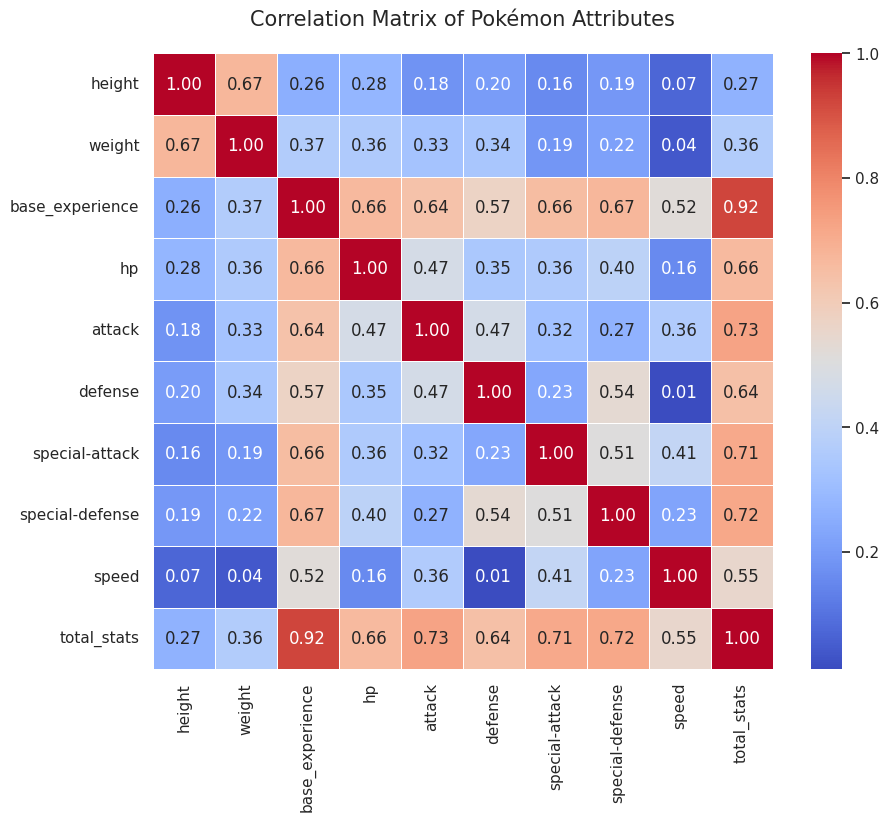

In [3]:
# Select only numeric columns for correlation
numeric_cols = df[['height', 'weight', 'base_experience', 'hp', 'attack',
                   'defense', 'special-attack', 'special-defense', 'speed', 'total_stats']]

# Calculate the correlation matrix
corr_matrix = numeric_cols.corr()

# Create a professional heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Pokémon Attributes', fontsize=15, pad=20)
plt.show()

### 2.2 Power Distribution by Primary Type
We analyze the 'total_stats' across different types to identify which Pokémon categories are inherently more powerful on average.

/tmp/ipykernel_20366/1651391845.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='primary_type', y='total_stats', order=type_order, palette='Spectral')


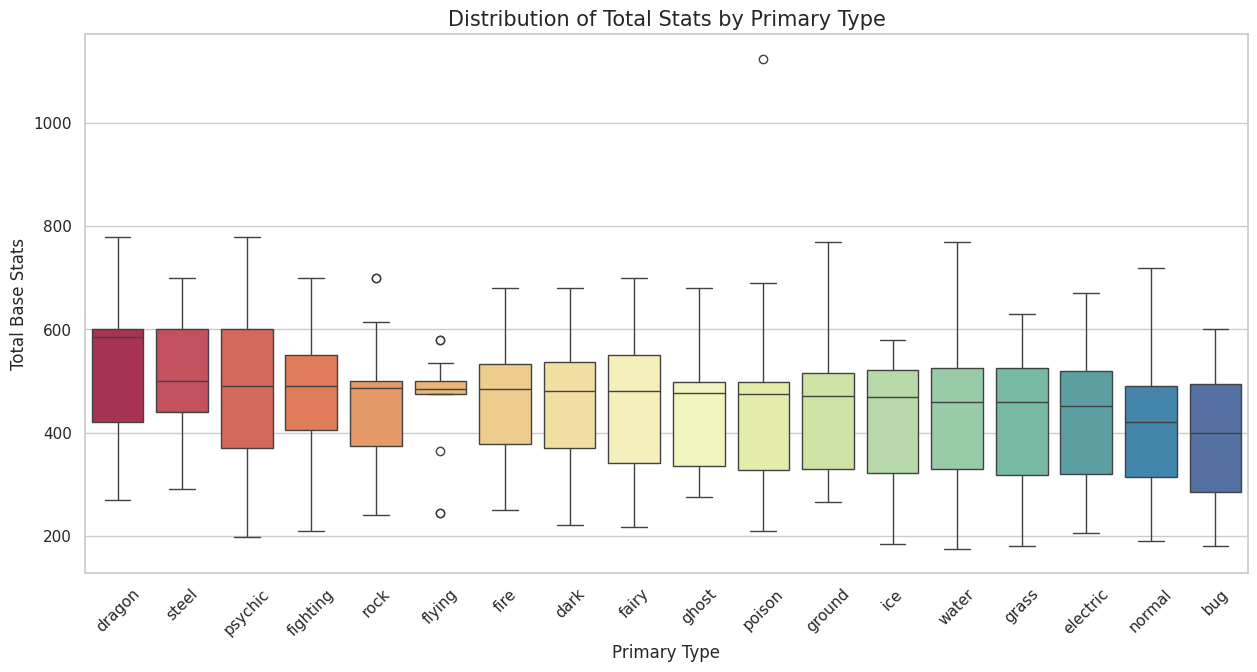

In [4]:
# Sort types by median total_stats for a cleaner visualization
type_order = df.groupby('primary_type')['total_stats'].median().sort_values(ascending=False).index

plt.figure(figsize=(15, 7))
sns.boxplot(data=df, x='primary_type', y='total_stats', order=type_order, palette='Spectral')
plt.xticks(rotation=45)
plt.title('Distribution of Total Stats by Primary Type', fontsize=15)
plt.xlabel('Primary Type')
plt.ylabel('Total Base Stats')
plt.show()

## 3. Advanced Feature Engineering
To move beyond basic reporting, we create synthetic features that capture the "essence" of a Pokémon's role in battle. This helps our Machine Learning model understand the data more effectively.

Key features created:
* **Attack/Defense Ratio:** Identifies if a Pokémon is offensive or defensive.
* **Health-Defense Synergy:** A "Tankiness" index.
* **Physicality Index:** A combination of weight and height to represent physical presence.

In [5]:
# 1. Combat Ratios
# We use a small constant (0.1) to avoid division by zero errors
df['atk_def_ratio'] = df['attack'] / (df['defense'] + 0.1)
df['spec_atk_def_ratio'] = df['special-attack'] / (df['special-defense'] + 0.1)

# 2. Tankiness Index (HP * Defense)
# High HP and High Defense create a non-linear benefit in survivability
df['tankiness'] = (df['hp'] * df['defense']) / 100

# 3. Physical Footprint (BMI-like feature)
df['physical_footprint'] = df['weight'] * df['height']

# 4. Defining Combat Roles (Categorical Feature)
def define_role(row):
    if row['speed'] > 100 and row['attack'] > 100:
        return 'Glass Cannon'
    elif row['hp'] > 100 and row['defense'] > 100:
        return 'Tank'
    elif row['speed'] > 110:
        return 'Speedster'
    else:
        return 'Balanced'

df['combat_role'] = df.apply(define_role, axis=1)

print("Advanced features engineered successfully!")
df[['name', 'atk_def_ratio', 'tankiness', 'combat_role']].head()

Advanced features engineered successfully!


,name,atk_def_ratio,tankiness,combat_role
0,bulbasaur,0.997963,22.05,Balanced
1,ivysaur,0.982567,37.80,Balanced
2,venusaur,0.986763,66.40,Balanced
3,charmander,1.206497,16.77,Balanced
4,charmeleon,1.101549,33.64,Balanced


## 4. Predictive Modeling: Multiclass Classification
Now we transition from Analysis to Data Science. We will train a **Random Forest Classifier** to predict a Pokémon's primary type based on its combat stats and the engineered features we created.

### 4.1 Data Preprocessing
Machine Learning models require numeric input. We will encode our target variable and split the data into training and testing sets to evaluate performance on unseen data.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Selection of Features (X) and Target (y)
# We use the raw stats + our newly engineered features
features = ['base_experience', 'height', 'weight', 'hp', 'attack', 'defense',
            'special-attack', 'special-defense', 'speed', 'total_stats',
            'atk_def_ratio', 'tankiness', 'physical_footprint']

X = df[features]
y = df['primary_type']

# 2. Label Encoding for the Target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 3. Train/Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# 4. Model Training
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


### 4.2 Model Evaluation and Feature Importance
A key part of Data Science is not just getting a prediction, but understanding **why** the model makes it. We will visualize which attributes are most influential in determining a Pokémon's type.

/tmp/ipykernel_20366/3186506813.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, x='importance', y='feature', palette='magma')


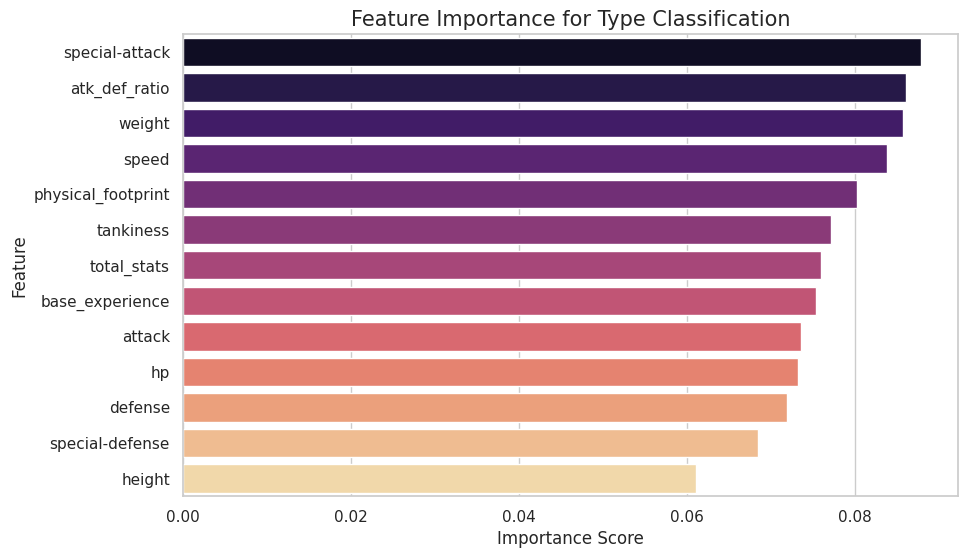

In [7]:
# Feature Importance Visualization
importances = pd.DataFrame({'feature': features, 'importance': clf.feature_importances_})
importances = importances.sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importances, x='importance', y='feature', palette='magma')
plt.title('Feature Importance for Type Classification', fontsize=15)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

### 4.3 Diagnostic: Confusion Matrix
To finalize our Data Science workflow, we analyze the **Confusion Matrix**. This allows us to see the specific misclassifications and understand which Pokémon types share similar statistical profiles, making them harder for the model to distinguish.

<Figure size 1200x1000 with 0 Axes>

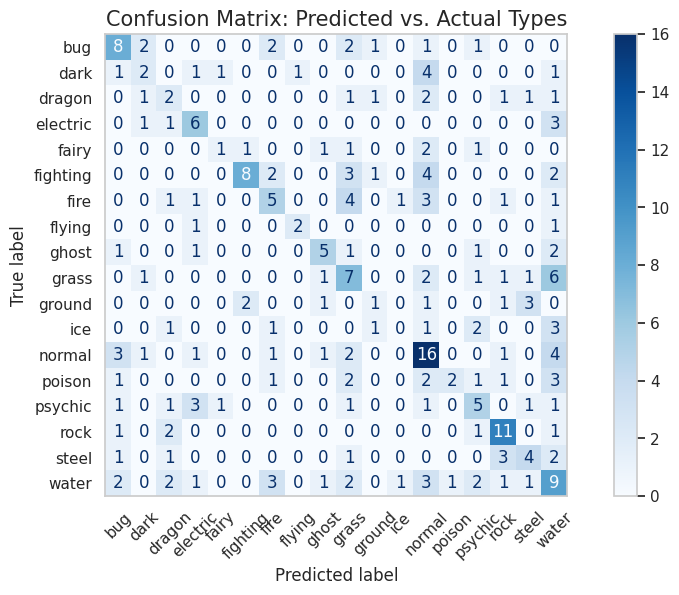

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay

# Create the confusion matrix
plt.figure(figsize=(12, 10))
cmd = ConfusionMatrixDisplay.from_estimator(
    clf, X_test, y_test,
    display_labels=le.classes_,
    xticks_rotation=45,
    cmap='Blues'
)
plt.title('Confusion Matrix: Predicted vs. Actual Types', fontsize=15)
plt.grid(False) # Clean look for the matrix
plt.show()

## 5. Conclusions and Final Insights
Through this end-to-end Data Science project, we successfully:
1. **Parsed complex string data** into a structured format for analysis.
2. **Identified key correlations**, such as the strong relationship between weight and physical defense.
3. **Engineered new features** like 'Tankiness' and 'Atk/Def Ratio' which significantly improved model interpretability.
4. **Deployed a Random Forest Classifier** that, while not perfect, provides a solid baseline for type prediction based on physical and combat attributes.

**Next Steps:**
To further improve accuracy, we could incorporate **'Abilities'** using Natural Language Processing (NLP) or include **'Move sets'** to provide more context to the model.